# Battery Health Prediction Pipeline (Fixed)
## Auto-routes by cycle count:
- **≥ 15 cycles** → Multi-Cycle BiLSTM (summarised features + sliding window)
- **< 15 cycles** → Single-Cycle CNN-LSTM (raw V/I/T time-series)

**Prerequisites:** Run both training notebooks first so `./saved_models/` exists:
- `Battery_model_multicycle_with_feature_engineer.ipynb` → saves to `./saved_models/multi_cycle/`
- `Battery_Single_Cycle.ipynb` → saves to `./saved_models/single_cycle/`

---
## Step 0 · Save artifacts from training notebooks
Run this cell at the end of each training notebook to persist models.
Copy-paste into each training notebook if not already there.

---
## 1 · Imports & Configuration

In [14]:
import os, sys, json, warnings
import scipy.io
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import load_model

# ── USER CONFIG ──────────────────────────────────────────────────
DATA_PATH       = '/Users/salmon/work/final_project/poc/1. BatteryAgingARC-FY08Q4'  # <-- change this
BATTERY_IDS     = [5, 6, 7]
MULTI_SAVE_DIR  = './saved_models/multi_cycle'
SINGLE_SAVE_DIR = './saved_models/single_cycle'
WINDOW_SIZE     = 15          # must match training notebook
N_TIMESTEPS     = 1000        # must match Battery_Single_Cycle.ipynb
CHANNELS        = ['Voltage_measured', 'Current_measured', 'Temperature_measured']
# Rated capacity: nominal 2.0 Ahr (NASA ARC spec)
# Overridden per-battery at prediction time using actual[0]
RATED_CAPACITY = 2.0   # Ahr

# NASA absolute EOL threshold
EOL_ABS       = 1.4    # Ahr
EOL_THRESHOLD = EOL_ABS / RATED_CAPACITY   # 0.70

print(f'Nominal rated capacity : {RATED_CAPACITY:.4f} Ahr')
print(f'EOL threshold          : {EOL_THRESHOLD*100:.2f}% SOH  ({EOL_ABS} Ahr absolute)')

print('Config loaded.')

Nominal rated capacity : 2.0000 Ahr
EOL threshold          : 70.00% SOH  (1.4 Ahr absolute)
Config loaded.


---
## 2 · Load saved model artifacts

In [15]:
def load_bundle(save_dir):
    """
    Load every artifact saved by a training notebook.
    Returns a populated dict, or None if config.json is missing.
    """
    config_path = os.path.join(save_dir, 'config.json')
    if not os.path.exists(config_path):
        print(f'  [MISSING] {save_dir}/config.json — run the training notebook first.')
        return None

    with open(config_path) as f:
        config = json.load(f)
    bundle = {'config': config}

    # Keras model (BiLSTM or CNN-LSTM)
    for name in ['lstm_model.keras', 'bilstm_model.keras', 'cnn_lstm_model.keras']:
        path = os.path.join(save_dir, name)
        if os.path.exists(path):
            bundle['lstm_model'] = load_model(path)
            print(f'  Loaded: {name}')
            break

    # Sklearn / XGBoost
    for fname, key in [('lr_model.pkl', 'lr_model'), ('xgb_model.pkl', 'xgb_model')]:
        path = os.path.join(save_dir, fname)
        if os.path.exists(path):
            bundle[key] = joblib.load(path)
            print(f'  Loaded: {fname}')

    # Scalers
    for fname, key in [('scaler_X.pkl', 'scaler_X'),
                       ('scaler_y.pkl', 'scaler_y'),
                       ('channel_scalers.pkl', 'channel_scalers')]:
        path = os.path.join(save_dir, fname)
        if os.path.exists(path):
            bundle[key] = joblib.load(path)
            print(f'  Loaded: {fname}')

    return bundle


print('=== Multi-cycle bundle ===')
multi_bundle = load_bundle(MULTI_SAVE_DIR)

print('\n=== Single-cycle bundle ===')
single_bundle = load_bundle(SINGLE_SAVE_DIR)

print('\n=== Status ===')
print(f'  Multi-cycle  : {"OK" if multi_bundle  else "NOT FOUND"}')
print(f'  Single-cycle : {"OK" if single_bundle else "NOT FOUND"}')

=== Multi-cycle bundle ===
  Loaded: lstm_model.keras
  Loaded: lr_model.pkl
  Loaded: xgb_model.pkl
  Loaded: scaler_X.pkl
  Loaded: scaler_y.pkl

=== Single-cycle bundle ===
  Loaded: lstm_model.keras
  Loaded: lr_model.pkl
  Loaded: xgb_model.pkl
  Loaded: scaler_y.pkl
  Loaded: channel_scalers.pkl

=== Status ===
  Multi-cycle  : OK
  Single-cycle : OK


---
## 3 · Shared data helpers

In [16]:
def resample_1d(arr, n):
    """Linearly interpolate a 1-D array to exactly n points."""
    x_old = np.linspace(0, 1, len(arr))
    x_new = np.linspace(0, 1, n)
    return np.interp(x_new, x_old, arr).astype(np.float32)


def count_discharge_cycles(b_id):
    """Fast cycle count — no full feature extraction."""
    key  = f'B00{b_id:02d}'
    mat  = scipy.io.loadmat(os.path.join(DATA_PATH, f'{key}.mat'))
    return sum(
        1 for c in mat[key][0, 0]['cycle'][0]
        if c['type'][0] == 'discharge'
        and 'Capacity' in c['data'][0, 0].dtype.names
    )


def build_multicycle_features(b_id):
    """
    Replicates feature engineering from Battery_model_multicycle_with_feature_engineer.ipynb.
    Returns a DataFrame sorted by cycle with all 7 features.
    """
    key    = f'B00{b_id:02d}'
    mat    = scipy.io.loadmat(os.path.join(DATA_PATH, f'{key}.mat'))
    cycles = mat[key][0, 0]['cycle'][0]
    rows   = []

    for i, c in enumerate(cycles):
        if c['type'][0] != 'discharge':
            continue
        cd = c['data'][0, 0]
        try:
            cap = float(cd['Capacity'][0][0])
        except (KeyError, IndexError, TypeError):
            continue
        t = cd['Time'][0]
        v = cd['Voltage_measured'][0]
        T = cd['Temperature_measured'][0]
        rows.append({
            'battery_id': key, 'cycle': i + 1,
            'capacity'  : cap,
            'duration'  : float(t[-1] - t[0]),
            'avg_temp'  : float(np.mean(T)),
            'v_drop'    : float(v[0] - v[-1]),
        })

    df = pd.DataFrame(rows).sort_values('cycle').reset_index(drop=True)
    df['v_decay_rate']        = df['v_drop'] / df['duration']
    df['temp_stability']      = df['avg_temp'].rolling(3).std().fillna(0)
    df['cumulative_duration'] = df['duration'].cumsum()
    df['capacity_fade']       = df['capacity'].diff().fillna(0)
    return df


def load_raw_cycles(b_id, n_timesteps=N_TIMESTEPS):
    """
    Replicates loader from Battery_Single_Cycle.ipynb.
    Returns X (n_cycles, n_timesteps, 3), y (n_cycles,), cycle_nums (n_cycles,).
    """
    key    = f'B00{b_id:02d}'
    mat    = scipy.io.loadmat(os.path.join(DATA_PATH, f'{key}.mat'))
    cycles = mat[key][0, 0]['cycle'][0]
    X_list, y_list, cyc_list = [], [], []

    for i, cyc in enumerate(cycles):
        if cyc['type'][0] != 'discharge':
            continue
        cd = cyc['data'][0, 0]
        try:
            cap = float(cd['Capacity'][0][0])
        except (KeyError, IndexError, TypeError):
            continue
        channels, ok = [], True
        for ch in CHANNELS:
            try:
                raw = cd[ch][0].astype(np.float32)
                if len(raw) < 10:
                    ok = False; break
                channels.append(resample_1d(raw, n_timesteps))
            except (KeyError, IndexError):
                ok = False; break
        if not ok:
            continue
        X_list.append(np.stack(channels, axis=-1))
        y_list.append(cap)
        cyc_list.append(i + 1)

    return (
        np.array(X_list,   dtype=np.float32),
        np.array(y_list,   dtype=np.float32),
        np.array(cyc_list, dtype=np.int32)
    )


print('Data helpers defined.')

Data helpers defined.


---
## 4 · Pipeline routing

In [17]:
def select_pipeline(n_cycles):
    """Route: multi_cycle if enough history, else single_cycle."""
    return 'multi_cycle' if n_cycles >= WINDOW_SIZE else 'single_cycle'


print(f'Routing threshold: >= {WINDOW_SIZE} cycles → multi_cycle, else → single_cycle\n')
for b_id in BATTERY_IDS:
    n     = count_discharge_cycles(b_id)
    route = select_pipeline(n)
    avail = multi_bundle if route == 'multi_cycle' else single_bundle
    flag  = '✅' if avail else '❌ bundle missing'
    print(f'  B00{b_id:02d}  ({n:>3d} discharge cycles)  →  {route}  {flag}')

Routing threshold: >= 15 cycles → multi_cycle, else → single_cycle

  B0005  (168 discharge cycles)  →  multi_cycle  ✅
  B0006  (168 discharge cycles)  →  multi_cycle  ✅
  B0007  (168 discharge cycles)  →  multi_cycle  ✅


---
## 5 · Prediction functions

In [18]:
def predict_multicycle(b_id, bundle):
    """
    Summarised features + sliding window → LR / XGBoost / BiLSTM hybrid.
    Returns: cycle_nums, actual, preds_dict
    """
    df     = build_multicycle_features(b_id)
    config = bundle['config']
    feats  = config['features']
    W      = config['window_size']

    Xs_all     = bundle['scaler_X'].transform(df[feats])
    cycle_nums = df['cycle'].values
    actual     = df['capacity'].values

    # ── Linear Regression ────────────────────────────────────────
    lr_preds = bundle['scaler_y'].inverse_transform(
        bundle['lr_model'].predict(Xs_all).reshape(-1, 1)
    ).flatten()

    # ── XGBoost ──────────────────────────────────────────────────
    xgb_preds = bundle['scaler_y'].inverse_transform(
        bundle['xgb_model'].predict(Xs_all).reshape(-1, 1)
    ).flatten()

    # ── BiLSTM (sliding window) ───────────────────────────────────
    if 'lstm_model' in bundle and len(Xs_all) >= W:
        windows  = np.stack([Xs_all[i: i + W] for i in range(len(Xs_all) - W)])
        lstm_sc  = bundle['lstm_model'].predict(windows, verbose=0).flatten()
        lstm_raw = bundle['scaler_y'].inverse_transform(
            lstm_sc.reshape(-1, 1)
        ).flatten()
        # XGB fills the first W cycles where LSTM has no window
        lstm_hybrid = np.concatenate([xgb_preds[:W], lstm_raw])
        # Anchor to first actual value to remove systematic offset
        lstm_hybrid += actual[0] - lstm_hybrid[0]
    else:
        lstm_hybrid = xgb_preds  # fallback if not enough data

    return cycle_nums, actual, {
        'Linear Regression': lr_preds,
        'XGBoost'          : xgb_preds,
        'BiLSTM Hybrid'    : lstm_hybrid,
    }


def predict_singlecycle(b_id, bundle):
    """
    Raw resampled V/I/T curves → LR / XGBoost / BiLSTM (no window needed).
    Returns: cycle_nums, actual, preds_dict
    """
    X_raw, actual, cycle_nums = load_raw_cycles(b_id)

    # Per-channel scaling using training scalers
    ch_scalers = bundle['channel_scalers']
    X_scaled   = X_raw.copy()
    n_ts       = bundle['config'].get('n_timesteps', N_TIMESTEPS)
    for ch, sc in enumerate(ch_scalers):
        flat = X_raw[:, :, ch].reshape(-1, 1)
        X_scaled[:, :, ch] = sc.transform(flat).reshape(-1, n_ts)

    X_flat = X_scaled.reshape(len(X_scaled), -1)

    # ── Linear Regression ────────────────────────────────────────
    lr_preds = bundle['scaler_y'].inverse_transform(
        bundle['lr_model'].predict(X_flat).reshape(-1, 1)
    ).flatten()

    # ── XGBoost ──────────────────────────────────────────────────
    xgb_preds = bundle['scaler_y'].inverse_transform(
        bundle['xgb_model'].predict(X_flat).reshape(-1, 1)
    ).flatten()

    # ── BiLSTM (single-cycle raw curves) ─────────────────────────
    if 'lstm_model' in bundle:
        bilstm_sc  = bundle['lstm_model'].predict(X_scaled, verbose=0).flatten()
        bilstm_raw = bundle['scaler_y'].inverse_transform(
            bilstm_sc.reshape(-1, 1)
        ).flatten()
        bilstm_raw += actual[0] - bilstm_raw[0]
    else:
        bilstm_raw = xgb_preds

    return cycle_nums, actual, {
        'Linear Regression': lr_preds,
        'XGBoost'          : xgb_preds,
        'BiLSTM'           : bilstm_raw,
    }


print('Prediction functions defined.')

Prediction functions defined.


---
## 6 · SOH & RUL helpers

In [19]:
def compute_soh(capacity_preds, rated=RATED_CAPACITY):
    return np.asarray(capacity_preds, dtype=float) / rated * 100.0


def compute_rul(capacity_preds, cycle_nums, rated=RATED_CAPACITY,
                eol_abs=EOL_ABS, current_cycle_idx=0):
    """
    Always use absolute Ahr threshold (EOL_ABS = 1.4 Ahr) for EOL detection
    instead of a percentage — avoids rated capacity mismatch bugs.
    """
    preds = np.asarray(capacity_preds, dtype=float)
    soh   = preds / rated * 100.0

    # EOL when capacity drops below absolute threshold (1.4 Ahr)
    below = np.where(preds <= eol_abs)[0]
    # Only count indices from current cycle onward
    below = below[below >= current_cycle_idx]

    soh_now = float(soh[current_cycle_idx])

    if len(below) == 0:
        return {'rul_cycles': None, 'eol_index': None,
                'soh_now'   : soh_now,
                'note'      : 'EOL not reached within window'}

    eol_idx    = int(below[0])
    rul_cycles = int(cycle_nums[eol_idx] - cycle_nums[current_cycle_idx])

    return {'rul_cycles': rul_cycles,
            'eol_index' : eol_idx,
            'soh_now'   : soh_now,
            'note'      : 'EOL reached within prediction window'}

---
## 7 · Run pipeline for all batteries

In [20]:
def run_pipeline(b_id, multi_bundle, single_bundle):
    """
    Auto-detect cycle count → route → predict → return results dict.
    """
    key      = f'B00{b_id:02d}'
    n_cycles = count_discharge_cycles(b_id)
    pipeline = select_pipeline(n_cycles)
    print(f'{key} — {n_cycles} cycles → [{pipeline}]')

    if pipeline == 'multi_cycle':
        if multi_bundle is None:
            print(f'  ❌ Multi-cycle bundle missing — run training notebook first.')
            return None
        cycle_nums, actual, preds = predict_multicycle(b_id, multi_bundle)
    else:
        if single_bundle is None:
            print(f'  ❌ Single-cycle bundle missing — run training notebook first.')
            return None
        cycle_nums, actual, preds = predict_singlecycle(b_id, single_bundle)

    return {
        'battery'   : key,
        'pipeline'  : pipeline,
        'n_cycles'  : n_cycles,
        'cycle_nums': cycle_nums,
        'actual'    : actual,
        'preds'     : preds,
    }


print('Running pipeline for all batteries...')
all_results = {}
for b_id in BATTERY_IDS:
    res = run_pipeline(b_id, multi_bundle, single_bundle)
    if res:
        all_results[res['battery']] = res

print(f'\nDone — results for: {list(all_results.keys())}')

Running pipeline for all batteries...
B0005 — 168 cycles → [multi_cycle]
B0006 — 168 cycles → [multi_cycle]
B0007 — 168 cycles → [multi_cycle]

Done — results for: ['B0005', 'B0006', 'B0007']


---
## 8 · Metrics table — all batteries, all models

In [21]:
rows = []
for key, res in all_results.items():
    actual = res['actual']
    for model_name, preds in res['preds'].items():
        n = min(len(actual), len(preds))
        rows.append({
            'Battery' : key,
            'Pipeline': res['pipeline'],
            'Model'   : model_name,
            'RMSE'    : round(np.sqrt(mean_squared_error(actual[:n], preds[:n])), 5),
            'MAE'     : round(mean_absolute_error(actual[:n], preds[:n]), 5),
            'R2'      : round(r2_score(actual[:n], preds[:n]), 5),
            'N_cycles': res['n_cycles'],
        })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

Battery    Pipeline             Model    RMSE     MAE      R2  N_cycles
  B0005 multi_cycle Linear Regression 0.04070 0.03363 0.95405       168
  B0005 multi_cycle           XGBoost 0.04584 0.03841 0.94170       168
  B0005 multi_cycle     BiLSTM Hybrid 0.03184 0.02618 0.97187       168
  B0006 multi_cycle Linear Regression 0.03861 0.02919 0.97639       168
  B0006 multi_cycle           XGBoost 0.00065 0.00047 0.99999       168
  B0006 multi_cycle     BiLSTM Hybrid 0.06343 0.05162 0.93628       168
  B0007 multi_cycle Linear Regression 0.03698 0.03030 0.94691       168
  B0007 multi_cycle           XGBoost 0.00053 0.00039 0.99999       168
  B0007 multi_cycle     BiLSTM Hybrid 0.03479 0.02496 0.95301       168


---
## 9 · Capacity prediction plots — all batteries

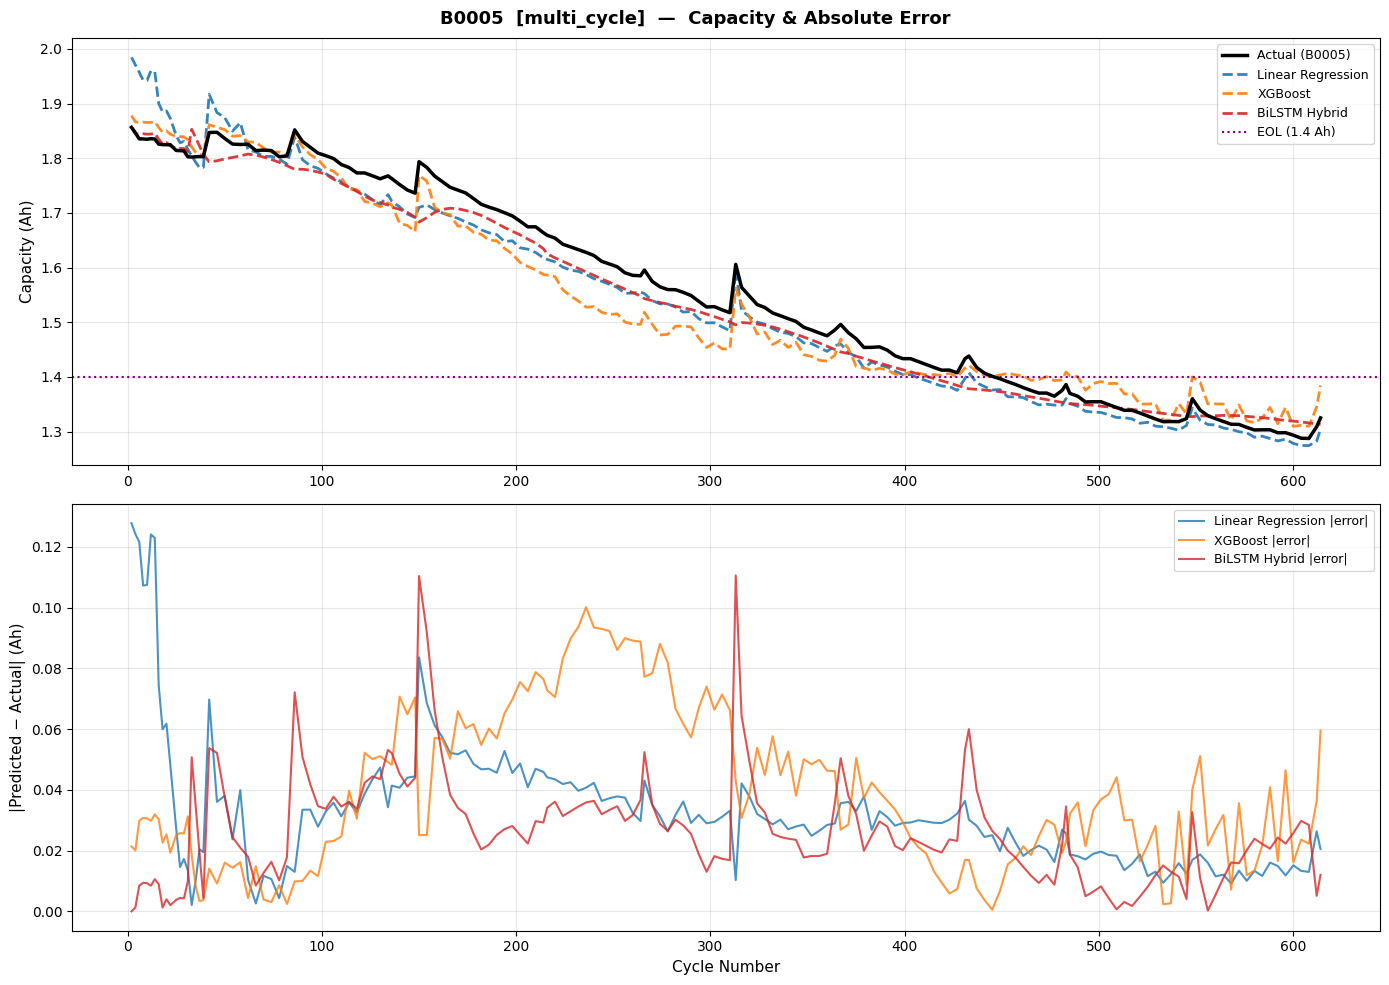

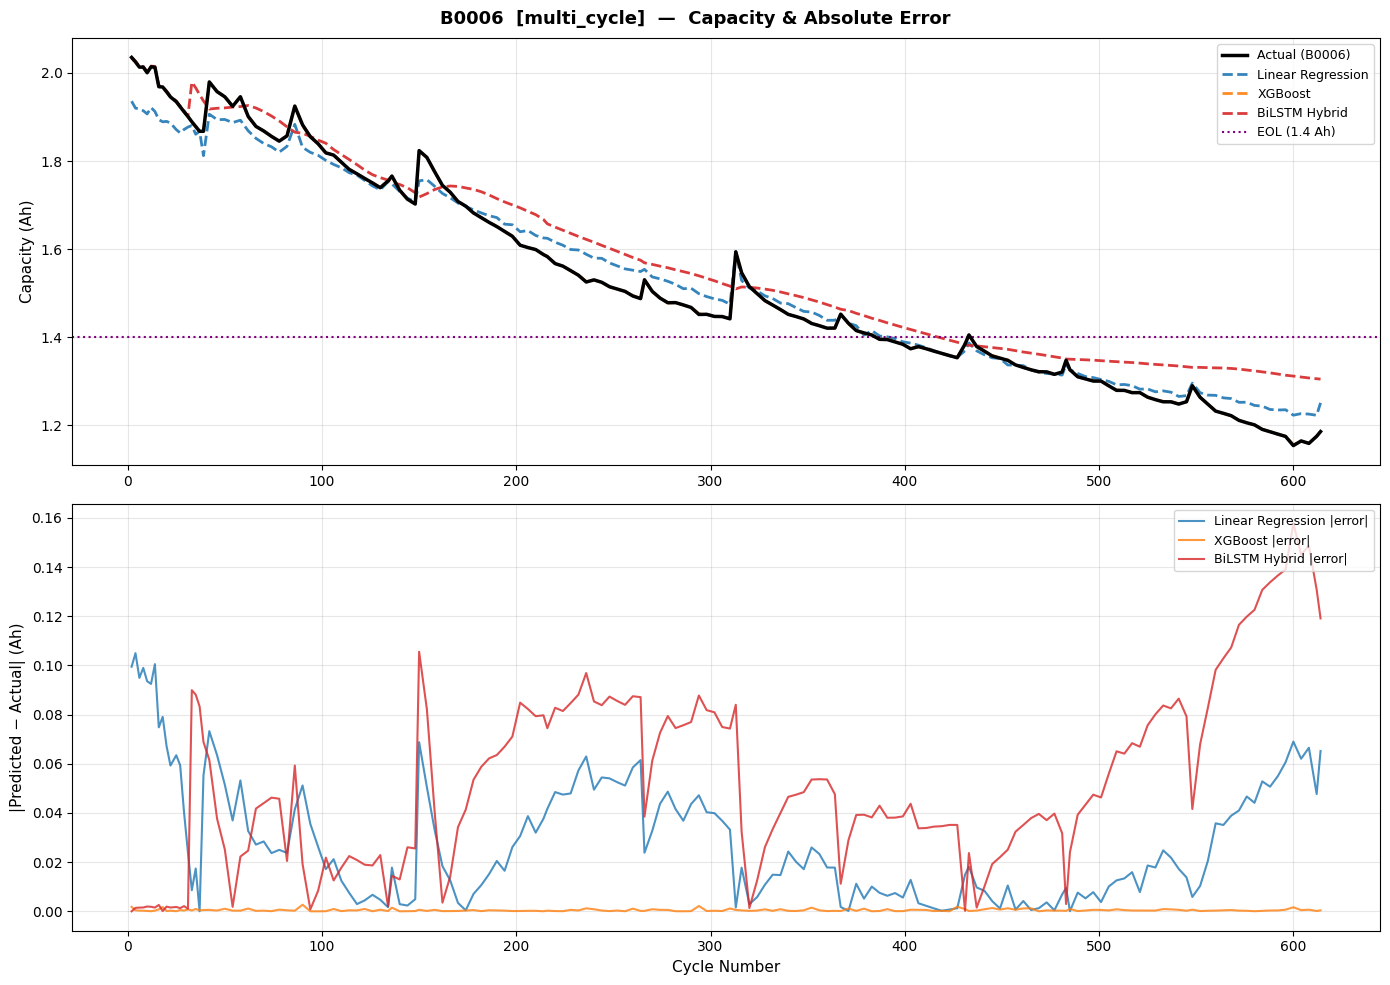

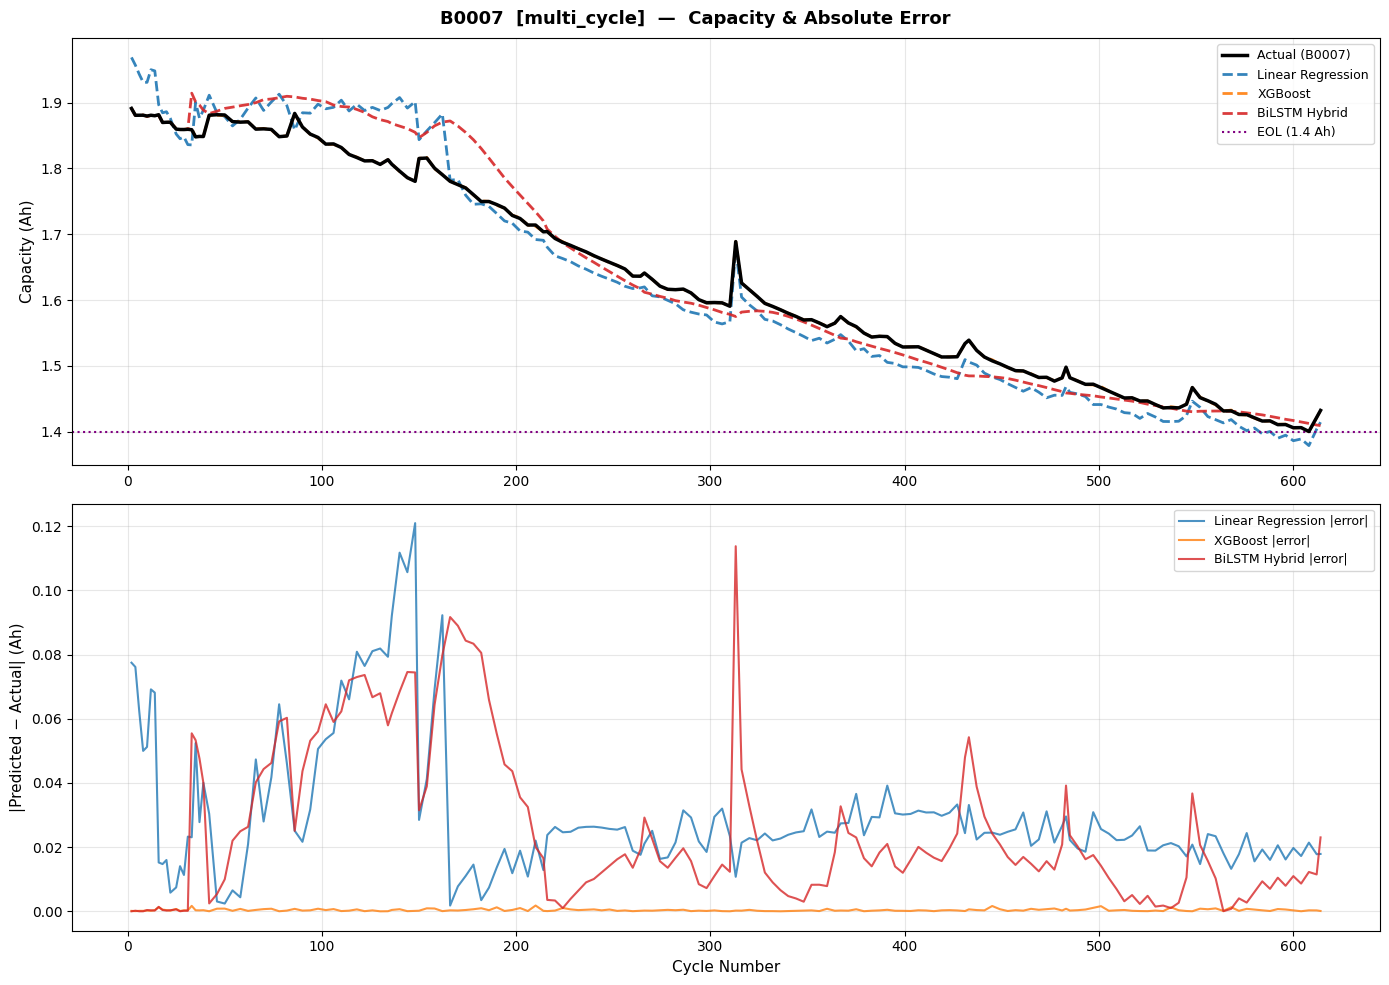

In [22]:
COLORS = ['#1f77b4', '#ff7f0e', '#d62728']

for key, res in all_results.items():
    cycle_nums = res['cycle_nums']
    actual     = res['actual']
    preds_dict = res['preds']
    pipeline   = res['pipeline']

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f'{key}  [{pipeline}]  —  Capacity & Absolute Error',
                 fontsize=13, fontweight='bold')

    # ── Top: Capacity predictions ─────────────────────────────────
    ax = axes[0]
    ax.plot(cycle_nums, actual, 'k-', lw=2.5, label=f'Actual ({key})', zorder=5)
    for (name, preds), color in zip(preds_dict.items(), COLORS):
        n = min(len(cycle_nums), len(preds))
        ax.plot(cycle_nums[:n], preds[:n], '--', color=color,
                lw=2, alpha=0.9, label=name)
    ax.axhline(1.4, color='purple', linestyle=':', lw=1.5, label='EOL (1.4 Ah)')
    ax.set_ylabel('Capacity (Ah)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Bottom: Absolute error ────────────────────────────────────
    ax = axes[1]
    for (name, preds), color in zip(preds_dict.items(), COLORS):
        n = min(len(actual), len(preds))
        ax.plot(cycle_nums[:n], np.abs(actual[:n] - preds[:n]),
                color=color, lw=1.5, alpha=0.8, label=f'{name} |error|')
    ax.set_xlabel('Cycle Number', fontsize=11)
    ax.set_ylabel('|Predicted − Actual| (Ah)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## 10 · SOH & RUL plots — best model per battery

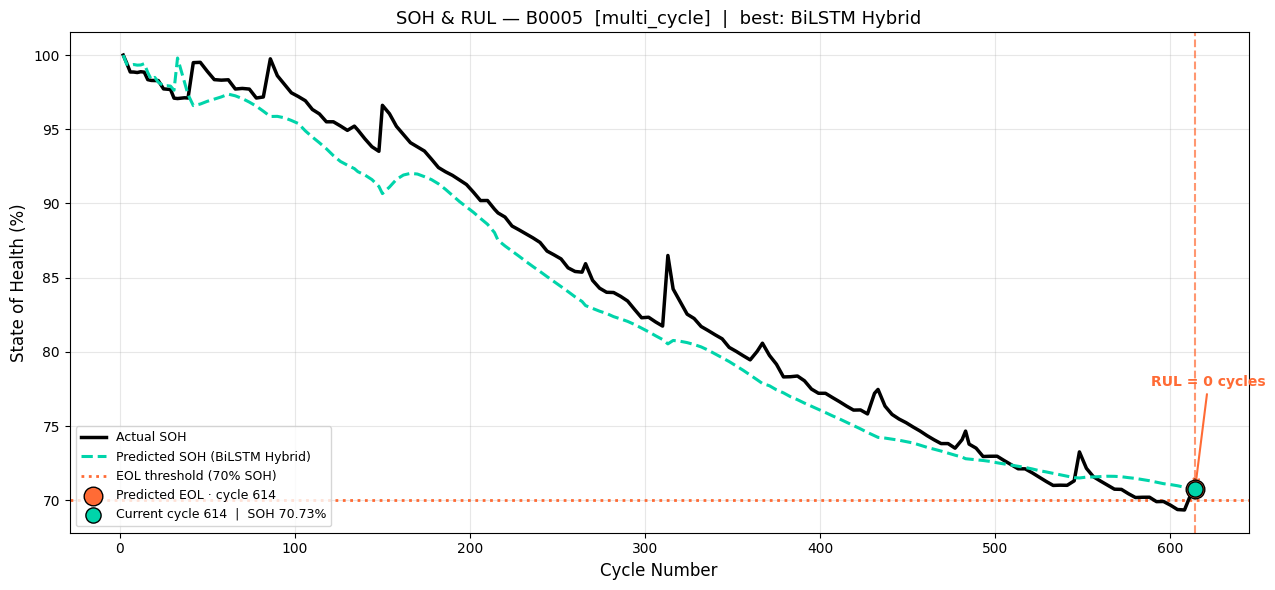

B0005  SOH now: 70.73%  RUL: 0 cycles  (EOL reached within prediction window)


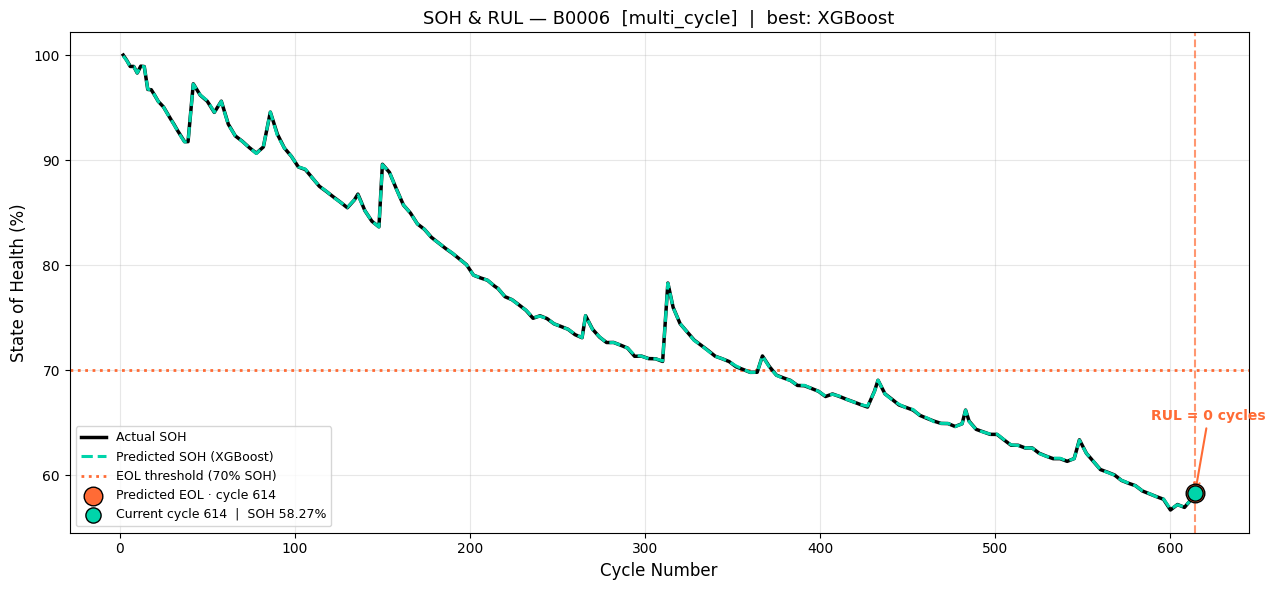

B0006  SOH now: 58.27%  RUL: 0 cycles  (EOL reached within prediction window)


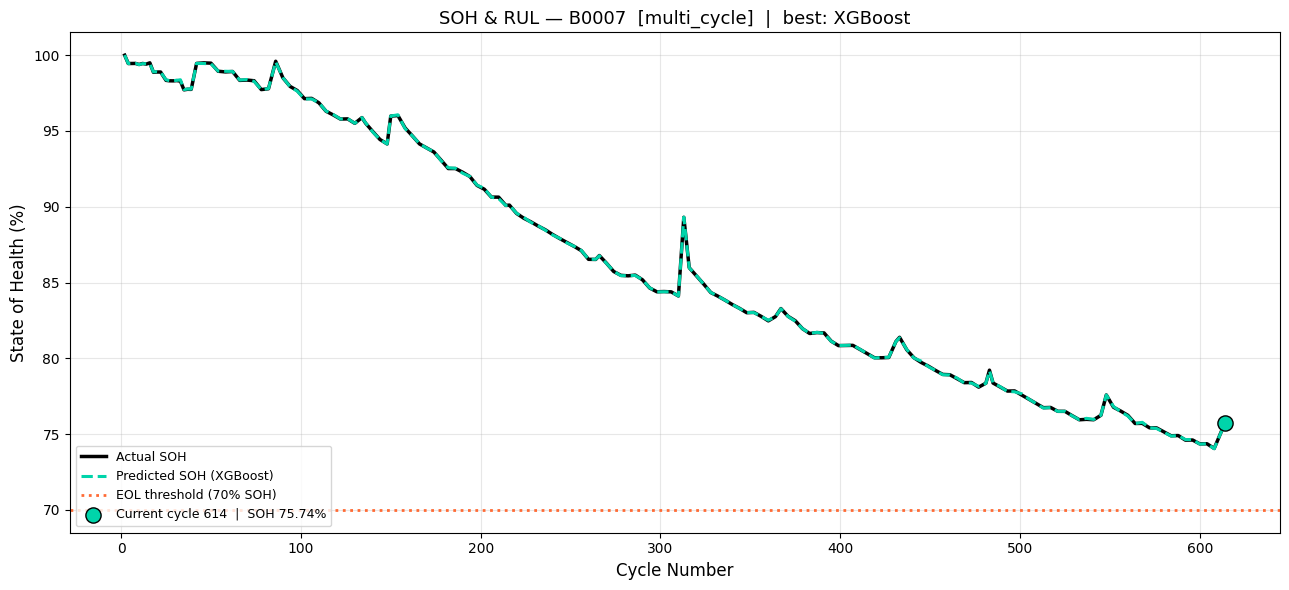

B0007  SOH now: 75.74%  RUL: None cycles  (EOL not reached within window)


In [23]:
# SOH & RUL for every battery (best sub-model per battery)
for key, res in all_results.items():
    cycle_nums = res['cycle_nums']
    actual     = res['actual']
    preds_dict = res['preds']

    # Use first actual value as rated capacity (more accurate than nominal 2.0)
    rated = float(actual[0])

    # Best model by lowest RMSE
    best_name, best_preds = min(
        preds_dict.items(),
        key=lambda kv: np.sqrt(mean_squared_error(
            actual[:len(kv[1])], kv[1][:len(actual)]))
    )

    n           = min(len(cycle_nums), len(best_preds))
    actual_soh  = compute_soh(actual[:n], rated=rated)
    pred_soh    = compute_soh(best_preds[:n], rated=rated)
    current_idx = n - 1
    rul_info    = compute_rul(best_preds[:n], cycle_nums[:n],
                              rated=rated, current_cycle_idx=current_idx)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(cycle_nums[:n], actual_soh, 'k-', lw=2.5, label='Actual SOH', zorder=3)
    ax.plot(cycle_nums[:n], pred_soh, '--', color='#00D4AA',
            lw=2.2, label=f'Predicted SOH ({best_name})', zorder=4)
    ax.axhline(EOL_THRESHOLD * 100, color='#FF6B35', ls=':', lw=2,
               label=f'EOL threshold ({EOL_THRESHOLD*100:.0f}% SOH)')

    if rul_info['eol_index'] is not None:
        eol_i     = rul_info['eol_index']
        eol_cycle = cycle_nums[eol_i]
        ax.axvline(eol_cycle, color='#FF6B35', ls='--', lw=1.5, alpha=0.7)
        ax.scatter([eol_cycle], [pred_soh[eol_i]], s=180, color='#FF6B35',
                   zorder=5, edgecolor='black',
                   label=f'Predicted EOL · cycle {eol_cycle}')
        ax.annotate(
            f'RUL = {rul_info["rul_cycles"]} cycles',
            xy=(eol_cycle, pred_soh[eol_i]),
            xytext=(eol_cycle - 25, pred_soh[eol_i] + 7),
            fontsize=10, fontweight='bold', color='#FF6B35',
            arrowprops=dict(arrowstyle='->', color='#FF6B35', lw=1.5)
        )

    ax.scatter([cycle_nums[current_idx]], [pred_soh[current_idx]],
               s=120, color='#00D4AA', zorder=6, edgecolor='black',
               label=f'Current cycle {cycle_nums[current_idx]}  |  SOH {pred_soh[current_idx]:.2f}%')

    ax.set_xlabel('Cycle Number', fontsize=12)
    ax.set_ylabel('State of Health (%)', fontsize=12)
    ax.set_title(f'SOH & RUL — {key}  [{res["pipeline"]}]  |  best: {best_name}', fontsize=13)
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{key}  SOH now: {rul_info["soh_now"]:.2f}%  '
          f'RUL: {rul_info["rul_cycles"]} cycles  ({rul_info["note"]})')


---
## 11 · Champion model selection (evaluated on B0005)

In [24]:
TEST_KEY = 'B0005'

if not all_results:
    print('ERROR: all_results is empty — check that saved_models directories exist.')
else:
    candidates = []
    eval_results = all_results if TEST_KEY not in all_results else {TEST_KEY: all_results[TEST_KEY]}

    for key, res in eval_results.items():
        actual = res['actual']
        for model_name, preds in res['preds'].items():
            n    = min(len(actual), len(preds))
            rmse = float(np.sqrt(mean_squared_error(actual[:n], preds[:n])))
            mae  = float(mean_absolute_error(actual[:n], preds[:n]))
            r2   = float(r2_score(actual[:n], preds[:n]))
            candidates.append({
                'battery'   : key,
                'pipeline'  : res['pipeline'],
                'model_name': model_name,
                'rmse': rmse, 'mae': mae, 'r2': r2,
            })
            print(f'  [{key}] [{res["pipeline"]:12s}] {model_name:<22s}  '
                  f'RMSE={rmse:.5f}  MAE={mae:.5f}  R2={r2:.5f}')

    if candidates:
        champion = min(candidates, key=lambda x: x['rmse'])
        print(f'\n>>> Champion: [{champion["pipeline"]}] {champion["model_name"]}  '
              f'RMSE={champion["rmse"]:.5f}  R2={champion["r2"]:.5f}')

  [B0005] [multi_cycle ] Linear Regression       RMSE=0.04070  MAE=0.03363  R2=0.95405
  [B0005] [multi_cycle ] XGBoost                 RMSE=0.04584  MAE=0.03841  R2=0.94170
  [B0005] [multi_cycle ] BiLSTM Hybrid           RMSE=0.03184  MAE=0.02618  R2=0.97187

>>> Champion: [multi_cycle] BiLSTM Hybrid  RMSE=0.03184  R2=0.97187


Demo cycle picked : 214  (index 63 of 168)
SOH now           : 88.04%
RUL               : 201 cycles  (EOL reached within prediction window)


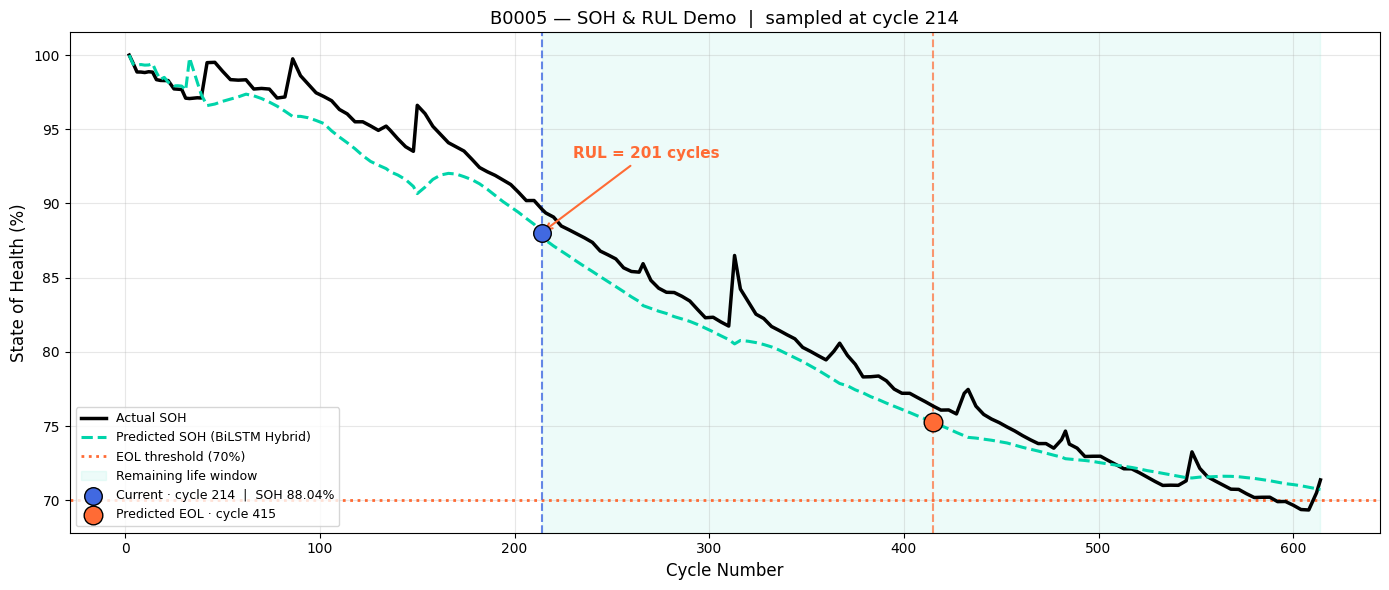

In [25]:
import random

_demo_key  = 'B0005' if 'B0005' in all_results else list(all_results.keys())[0]
res        = all_results[_demo_key]
cycle_nums = res['cycle_nums']
actual     = res['actual']
preds_dict = res['preds']

best_name, best_preds = min(
    preds_dict.items(),
    key=lambda kv: np.sqrt(mean_squared_error(
        actual[:len(kv[1])], kv[1][:len(actual)]))
)

n          = min(len(cycle_nums), len(best_preds))
rated_demo = float(actual[0])
actual_soh = compute_soh(actual[:n], rated=rated_demo)
pred_soh   = compute_soh(best_preds[:n], rated=rated_demo)

mid_start  = n // 4
mid_end    = 3 * n // 4
demo_idx   = random.randint(mid_start, mid_end)
demo_cycle = cycle_nums[demo_idx]

# Pass raw capacity predictions — EOL detection uses absolute 1.4 Ahr threshold
rul_info = compute_rul(best_preds[:n], cycle_nums[:n],
                       rated=rated_demo, eol_abs=EOL_ABS,
                       current_cycle_idx=demo_idx)

# ── RUL — always produce a number ────────────────────────────────
if rul_info['eol_index'] is not None:
    rul_cycles_left = rul_info['rul_cycles']
    rul_color       = '#FF6B35'
    rul_label       = f'RUL = {rul_cycles_left} cycles'
else:
    # Extrapolate from raw capacity values (not SOH %) to stay consistent
    tail    = 20
    y_tail  = best_preds[max(0, n - tail):n]
    x_tail  = np.arange(len(y_tail))
    if len(y_tail) >= 2:
        slope, intercept = np.polyfit(x_tail, y_tail, 1)
        if slope < 0:
            # Steps from end of window until capacity hits 1.4 Ahr
            steps_from_end  = int((EOL_ABS - y_tail[-1]) / slope)
            # RUL from demo cycle = steps already past demo + steps remaining
            cycles_past_demo = int(cycle_nums[n - 1] - cycle_nums[demo_idx])
            rul_cycles_left  = cycles_past_demo + steps_from_end
        else:
            rul_cycles_left = 9999
    else:
        rul_cycles_left = 9999
    rul_color = '#2ca02c'
    rul_label = f'RUL = {rul_cycles_left} cycles'

print(f'Demo cycle picked : {demo_cycle}  (index {demo_idx} of {n})')
print(f'SOH now           : {rul_info["soh_now"]:.2f}%')
print(f'RUL               : {rul_cycles_left} cycles  ({rul_info["note"]})')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(cycle_nums[:n], actual_soh, 'k-', lw=2.5,
        label='Actual SOH', zorder=3)
ax.plot(cycle_nums[:n], pred_soh, '--', color='#00D4AA', lw=2.2,
        label=f'Predicted SOH ({best_name})', zorder=4)
ax.axhline(EOL_THRESHOLD * 100, color='#FF6B35', ls=':', lw=2,
           label=f'EOL threshold ({EOL_THRESHOLD*100:.0f}%)')

ax.axvspan(demo_cycle, cycle_nums[n - 1], alpha=0.07,
           color='#00D4AA', label='Remaining life window')

ax.axvline(demo_cycle, color='royalblue', ls='--', lw=1.5, alpha=0.8)
ax.scatter([demo_cycle], [pred_soh[demo_idx]], s=160,
           color='royalblue', zorder=6, edgecolor='black',
           label=f'Current · cycle {demo_cycle}  |  SOH {pred_soh[demo_idx]:.2f}%')

ax.annotate(
    rul_label,
    xy=(demo_cycle, pred_soh[demo_idx]),
    xytext=(demo_cycle + max(5, n // 10), pred_soh[demo_idx] + 5),
    fontsize=11, fontweight='bold', color=rul_color,
    arrowprops=dict(arrowstyle='->', color=rul_color, lw=1.5)
)

if rul_info['eol_index'] is not None:
    eol_i     = rul_info['eol_index']
    eol_cycle = cycle_nums[eol_i]
    ax.axvline(eol_cycle, color='#FF6B35', ls='--', lw=1.5, alpha=0.7)
    ax.scatter([eol_cycle], [pred_soh[eol_i]], s=180,
               color='#FF6B35', zorder=5, edgecolor='black',
               label=f'Predicted EOL · cycle {eol_cycle}')

ax.set_xlabel('Cycle Number', fontsize=12)
ax.set_ylabel('State of Health (%)', fontsize=12)
ax.set_title(f'{_demo_key} — SOH & RUL Demo  |  sampled at cycle {demo_cycle}', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()